<a href="https://colab.research.google.com/github/BMClab/h2a_age_spt/blob/main/notebooks/speed_age_spt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Effects of age and speed on step length and cadence during walking

> [Laboratory of Biomechanics and Motor Control](https://bmclab.pesquisa.ufabc.edu.br/)  
> Federal University of ABC, Brazil

## Introduction

This notebook contains data analysis to investigate the effects of speed and age on step length and cadence.

The experimental data are taken from an open dataset (Fukuchi et al., 2018). This dataset contains raw and processed data from standard 3-D gait analysis of healthy volunteers walking in both overground and treadmill in a range of speeds.

## Python setup

In [1]:
import os, sys
import json
from pathlib import Path
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.stats.api as sms
from tqdm import tqdm
if "google.colab" in sys.modules:
    %pip install -q pingouin
    %pip install -q watermark

import pingouin as pg

%load_ext watermark

### Environment

In [2]:
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
#palette = sns.color_palette(palette='Set1')  # tab10
#palette[0], palette[1] = palette[1], palette[0]
#sns.set_palette(palette=palette)
pd.set_option('display.precision', 3)  # number of decimal places for the environment
#pd.set_option('future.no_silent_downcasting', True)

# significance level
alpha = 0.05
# colors
#colors = sns.color_palette()
colors = plotly.colors.DEFAULT_PLOTLY_COLORS
colors2 = [tuple(np.fromstring(c[4:-1], sep=',')/255) for c in colors]

%watermark -u -t -d -m -v --iversions

Last updated: 2026-09-11 00:26:39

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 7.0.0-31-generic
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit

json       : 2.0.9
matplotlib : 3.11.1
numpy      : 2.5.2
pandas     : 3.0.5
pingouin   : 0.6.1
plotly     : 6.9.0
scipy      : 1.18.0
seaborn    : 0.13.2
statsmodels: 0.14.6
tqdm       : 4.70.0



### Helping functions

In [3]:
def ttest(df, feature, group, levels=None, alpha=.05):
    """Welch/independent t statistics with signed Cohen d: levels[0] minus levels[1].

    Explicit Older, Young calls report Older minus Young for d and percent difference.
    """
    stats = []
    if levels is None:
        levels = df[group].unique()
    if len(levels) != 2:
        raise Exception('Incorrect number of levels: {}'.format(len(levels)))
    for f in feature:
        x = df[df[group] == levels[0]][f]
        y = df[df[group] == levels[1]][f]
        stat = pg.ttest(x, y, confidence=1-alpha)
        # Pingouin reports absolute Cohen d; use the table's stated group direction.
        pooled_sd = np.sqrt(((len(x)-1)*x.var(ddof=1) + (len(y)-1)*y.var(ddof=1))
                            / (len(x)+len(y)-2))
        stat['cohen_d'] = (x.mean() - y.mean()) / pooled_sd
        stat.index = [f]
        diff = np.round(100 * (np.mean(x) - np.mean(y)) / np.mean(y), 0)
        diff = pd.DataFrame(data=diff, index=[f], columns=['%diff'], dtype=int)
        stat = pd.concat([stat, diff], axis=1)
        stats.append(stat)

    stats = [df.dropna(axis=1, how='all') for df in stats]
    stats = pd.concat(stats, axis=0)
    stats.drop(columns=['alternative', 'BF10', 'power'], inplace=True)
    stats.index.name = '{} minus {} (signed d)'.format(*levels)
    display(stats.style.format({'p_val': '{:.3f}'}).apply(sig_red, subset='p_val', axis=1))
    return stats


def normtest(df, feature, group, alpha=alpha):
    """Normality test for dataframe columns using the pingouin library.
    """
    levels = df[group].unique()
    for level in levels:
        test = pg.normality(df[df[group] == level][feature], method='normaltest')
        test.index.name = level
        display(test.style.format({'pval': '{:.3f}'}).apply(sig_red, axis=1))


def normality(df):
    """Get the p-val of the normality test using the pingouin library.
    """
    return pg.normality(df)['pval']


def describe(df, feature, group, stat=['count', 'mean', 'std', 'min', 'max', normality]):
    """Descriptive statistics for dataframe columns.
    """
    col = [('Young', 'normality'), ('Older', 'normality')]
    x = df.groupby(group)[feature].agg(stat).stack(future_stack=True).transpose().style.apply(sig_red, subset=col)
    display(x)
    return x


def sig_red(col, alpha=alpha):
    """Returns string 'color: red' for `col` < `alpha`, black otherwise.
    """
    col = np.array([(float(x.lstrip('<').strip()) if isinstance(x, str) else float(x))
                    if len(str(x)) else np.nan for x in col])

    is_sig = col < alpha
    return ['color: red' if x else 'color: black' for x in is_sig]


def regression(fit_ml, fit_re, names):
    """Get results from linear regression as list.

    results = ['Response', 'Coef', 'CI', 'p', 'Coef', 'CI', 'p', Coef', 'CI', 'p',
               'llf', 'AIC', 'R2']
    """
    # print(fit_re.model.exog_names)
    if names is None:
        names = fit_re.model.exog_names[1:]
    results = [np.nan]*(1 + len(names)*3 + 3)
    # response
    results[ 0] = fit_re.model.endog_names
    # log-likelihood function
    results[-3] = '{:.1f}'.format(fit_ml.llf)
    # Akaike information criterion
    results[-2] = '{:.1f}'.format(fit_ml.aic)
    # marginal R2, proportion of variance explained by the fixed factor(s) alone
    results[-1] = '{:.2f}'.format(np.corrcoef(fit_re.model.endog, fit_re.predict())[0, 1]**2)
    # conditional R2, proportion of variance explained by both the fixed and random factors
    #results[-1] = np.round(np.corrcoef(fit_re.model.endog , fit_re.fittedvalues)[0, 1]**2, 2)
    for name in fit_re.model.exog_names[1:]:
        idx = names.index(name)
        # fitted fixed-effects coefficients
        results[3*idx+1] = '{:.2f}'.format(fit_re.params[name])
        # confidence interval for the fitted parameters
        ci = fit_re.conf_int().loc[name].values
        results[3*idx+2] = '[{:.2f}, {:.2f}]'.format(ci[0], ci[1])
        # two-tailed p values for the t-stats of the params
        if fit_re.pvalues[name] < 0.0001:
            results[3*idx+3] = '< 0.0001'
        else:
            results[3*idx+3] = '{:.4f}'.format(fit_re.pvalues[name])

    return results


def runmodels(data, predictors, responses, groups, names, mixed=True, show=True, random_slopes=True):
    """Fit mixed models separately by ML/REML, or OLS once per formula."""
    fit_ml, fit_re, models = [], [], []
    for response in responses:
        for predictor in predictors:
            eq = f'{response} ~ {predictor}'
            if mixed:
                # Distinct model objects: MixedLM.fit mutates the model REML flag.
                # Age-only remains a random-intercept descriptive reference.
                re_formula = '~Speed' if random_slopes and 'Speed' in predictor else '1'
                ml = smf.mixedlm(eq, data, groups=groups, re_formula=re_formula).fit(reml=False)
                re = smf.mixedlm(eq, data, groups=groups, re_formula=re_formula).fit(reml=True)
                assert ml.converged and re.converged, f'Nonconverged: {eq}'
            else:
                ml = re = smf.ols(eq, data).fit()
            fit_ml.append(ml)
            fit_re.append(re)
            models.append(regression(ml, re, names=names))
            if show:
                print(f'Model {len(models):2}: {eq}' + ('; ML and REML converged.' if mixed else '; OLS.'))
    return models, fit_ml, fit_re


def display_table(models, names, del_name_idx=None, filename=None):
    """Display rich table with stats from regression models.
    """
    h0, h1, h2 = ['Feature'], ['Feature'], ['Feature']
    h0.extend(['Predictor']*3*len(names))
    for name in names:
        h1.extend(name*3)
    h2.extend(['Coef', 'CI', 'p-value']*len(names))
    h0.extend(['LLF', 'AIC', 'R2'])
    h1.extend(['LLF', 'AIC', 'R2'])
    h2.extend(['LLF', 'AIC', 'R2'])
    table = pd.DataFrame(data=models)
    table.columns=[h0, h1, h2]
    table.replace({np.nan: ''}, inplace=True)
    if del_name_idx is not None:
        for col in del_name_idx:
            table = table.drop(columns=names[col], level=1)
    table.index = table.index + 1
    if filename is not None:
        result_dir = ROOT / 'results'
        result_dir.mkdir(parents=True, exist_ok=True)
        table.to_csv(result_dir / filename, sep='\t', index=False)
    table = table.style \
            .apply(sig_red, subset=[c for c in table.columns if c[-1] == 'p-value']) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
    return table


def plot_residuals(fit=None, residuals=None, kind='marginal', x=None,
                   xlabel=None, ylabel=None, alpha=0.05, hover=None):
    """Scater plot, histogram and Q-Q plot for testing residuals.

    This function generates three subplots (1x3):
    1. Scatter plot of the residuals versus predictor variables.
    2. Histogram of the residuals and the expected normal function.
    3. Q-Q plot.

    On the third plot are also shown the statistic and p-value of the
    Shapiro-Wilk test for normality. These values are also returned as output
    of the function.

    Parameters
    ----------
    fit: statsmodels regression results or None, optional (default=None)
        `fit` is a mod.fit() structure
        See https://www.statsmodels.org/stable/regression.html
        The residuals and predictor values are taken from this parameter.

    residuals: 1-D array_like or None, optional (default=None)
        The residuals to test the normality. Enter this parameter only if
        `fit` is not inputed.

    kind: {'marginal', 'conditional'}, optional (default='marginal')
        Which kind of residuals to test (only if `fit` is inputed).
        'marginal': residuals from fixed effects
        'conditional': residuals from fixed and random effects

    x: 1-D array_like or None, optional (default=None)
        The predictor values.

    xlabel: string or None, optional (default=None)
        The predictor label.

    ylabel: string or None, optional (default=None)
        The response label.

    alpha: float, optional (default=0.05)
        The significance level

    hover: tuple (string, 1-D array_like) or None, optional (default=None)
        Information to show when hovering the data in the first plot.
        See the examples.


    Returns
    -------
    statistic: float
        The statistic of the Shapiro-Wilk test for normality.
    p-value: float
        The p-value of the null-hypothesis test for normality.

    Notes
    -----
    https://www.statsmodels.org/stable/_modules/statsmodels/regression/mixed_linear_model.html
    fit.predict() only reflect
     fixed effects mean structure of the model.
    fit.fittedvalues reflect the mean
     structure specified by fixed effects and predicted random effects.

    Examples
    --------
    >>> residuals = np.random.normal(loc=0.0, scale=1.0, size=1000)
    >>> plot_residuals(residuals=residuals)
    >>> residuals = np.random.lognormal(mean=1.0, sigma=0.5, size=100)
    >>> plot_residuals(residuals=residuals, xlabel= 'X', ylabel='Y')
    >>> residuals = np.random.lognormal(mean=1.0, sigma=0.5, size=10)
    >>> plot_residuals(residuals=residuals, hover=('Datum', np.arange(10)))
    """

    import numpy as np
    import scipy as sp
    import plotly
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    import plotly.figure_factory as ff

    if fit is not None:
        # fit.predict() only reflect
        #  fixed effects mean structure of the model.
        # fit.fittedvalues reflect the mean
        #  structure specified by fixed effects and predicted random effects.
        if kind == 'marginal':
            residuals = fit.model.endog - fit.predict()
        elif kind == 'conditional':
            residuals = fit.model.endog - fit.fittedvalues
        else:
            raise ValueError("Valid options for 'kind': 'marginal' or 'conditional'.")
        x = fit.model.exog[:, 1]
    else:
        if residuals is None:
            raise ValueError('If fit is None, residuals cannot be None.')
        if x is None:
            x = np.arange(0, len(residuals))
    if xlabel is None:
        xlabel = 'Predictor'
    if ylabel is None:
        ylabel = 'Response'

    # normality of residuals test
    W, p = sp.stats.shapiro(residuals)  # Shapiro-Wilk test
    if p < 0.001:
        p_str = 'p < 0.001'
    else:
        p_str = 'p = {:.3f}'.format(p)
    # plots
    fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.1,
                        subplot_titles=('Scatter plot', 'Histogram', 'Q-Q plot'))
    # scatter plot
    if hover is not None:
        label, data = hover[0], hover[1]
        template = ['<b>{}: '.format(label) + '%{customdata}</b> <br>' +
                    '{}: '.format(xlabel) + '%{x} <br>Residual: %{y} ']
        fig.add_trace(go.Scatter(x=x, y=residuals, mode='markers',
                                 marker=dict(color='blue'),
                                 customdata=data,
                                 hovertemplate=template[0],
                                 name=''),
                      row=1, col=1)
    else:
        fig.add_trace(go.Scatter(x=x, y=residuals, mode='markers', name='',
                                 marker=dict(color='blue')), row=1, col=1)
    if min(residuals)<=0 and max(residuals)>=0:
        fig.add_hline(y=0, line=dict(width=2, color='rgba(0,0,0,.5)'), row=1, col=1)
    # histogram
    fig.add_trace(go.Histogram(x=residuals, marker_color='blue', name='',
                               histnorm='probability density'), row=1, col=2)
    norm = ff.create_distplot([residuals], group_labels=[''],
                              curve_type='normal', show_rug=False).data[1]
    fig.add_trace(go.Scatter(x=norm['x'], y=norm['y'], mode = 'lines', name='',
                             line=dict(width=3, color='red')), row=1, col=2)
    # Q-Q plot
    qq = sp.stats.probplot(residuals, dist='norm')
    qqx = np.array([qq[0][0][0], qq[0][0][-1]])
    fig.add_trace(go.Scatter(x=qq[0][0], y=qq[0][1], mode='markers', name='',
                             marker=dict(color='blue')), row=1, col=3)
    fig.add_trace(go.Scatter(x=qqx, y=qq[1][1] + qq[1][0]*qqx, mode='lines', name='',
                             line=dict(width=3, color='red')), row=1, col=3)
    fig.add_annotation(text='W = {:.2f}<br>{}'.format(W, p_str),
                       xref='x domain', yref='y domain', align='left', valign='top',
                       x=0.02, y=0.98, showarrow=False, row=1, col=3)
    # x and y axes properties
    fig.update_xaxes(title_text=xlabel, row=1, col=1)
    fig.update_xaxes(title_text='Residuals', row=1, col=2)
    fig.update_xaxes(title_text='Normal theoretical quantiles', row=1, col=3)
    fig.update_yaxes(title_text='Residuals', row=1, col=1)
    fig.update_yaxes(title_text='Probability density', row=1, col=2)
    fig.update_yaxes(title_text='Observed data quantiles', row=1, col=3)

    text='Normality tests for residuals of {} &times; {}'.format(ylabel, xlabel)
    fig.update_layout(showlegend=False, height=400, font_color='black',
                      title=dict(text=text, x=.5, xanchor='center', yanchor='top',
                                 font=dict(size=20)))
    fig.show()
    print(['We {}reject the null hypothesis that the residuals come from a population' +
           ' with normal distribution\n(Shapiro-Wilk test: W({}) = {:.2f}, {}).'
          ][0].format('failed to ' if p>alpha else '', len(x), W, p_str))

    return W, p


def boxplots(df, var=['Speed', 'Cadence', 'StepLength']):
    """Boxplots of variables var in df
    """
    fig, axs = plt.subplots(1, len(var), figsize=(12, 3),
                            gridspec_kw={'hspace':.1, 'wspace':.5})
    for ax, v in zip(axs, var):
        sns.boxplot(x='AgeGroup', y=v, data=df, fliersize=9, ax=ax)
        sns.swarmplot(x='AgeGroup', y=v, data=df, ax=ax, color='gray')
        ax.set_title(v)
        ax.set_ylabel('')
    plt.show()

### Dataset location

In [4]:
ROOT = Path.cwd().resolve()
if not (ROOT / 'data').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'notebooks' / 'revision_analysis.py').is_file(), 'Run from the cloned repository or notebooks directory.'
path2 = ROOT / 'data'
filename = path2 / 'h2a_allspeeds_43subs.csv'
print(f'Dataset location: {filename}')

Dataset location: /home/marcos/github/bmclab/h2a_age_spt/data/h2a_allspeeds_43subs.csv


## Read data

In [5]:
df = pd.read_csv(filename)
#df['Cadence'] = df['Cadence'] / 60
df
assert df.Subject.nunique() == 43
assert len(df) == 258

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject     258 non-null    int64  
 1   AgeGroup    258 non-null    str    
 2   Gender      258 non-null    str    
 3   Age         258 non-null    int64  
 4   Height      258 non-null    float64
 5   Mass        258 non-null    float64
 6   BMI         258 non-null    float64
 7   LegLength   258 non-null    float64
 8   SpeedCat    258 non-null    str    
 9   SpeedComf   258 non-null    float64
 10  Speed       258 non-null    float64
 11  StepLength  258 non-null    float64
 12  Cadence     258 non-null    float64
 13  H2A_M       258 non-null    float64
 14  H2A_I       258 non-null    float64
 15  H2A_W       258 non-null    float64
dtypes: float64(11), int64(2), str(3)
memory usage: 32.4 KB


### Fresh analysis

All results are regenerated from the participant CSV; historical figure caches are not read.

In [7]:
assert df.groupby('Subject').SpeedCat.nunique().eq(6).all()
assert not df.duplicated(['Subject', 'SpeedCat']).any()

## Age-group comparison

In [8]:
# number of subjects in each group
Ny, No = df.drop_duplicates(subset='Subject')[['Subject', 'AgeGroup']
                                             ].groupby(['AgeGroup']).count().values
display(df.drop_duplicates(subset='Subject', inplace=False)[
        ['Subject', 'AgeGroup', 'Gender']].groupby(['AgeGroup', 'Gender']).count().T)

AgeGroup Older     Young    
Gender       F   M     F   M
Subject      9  12     8  14

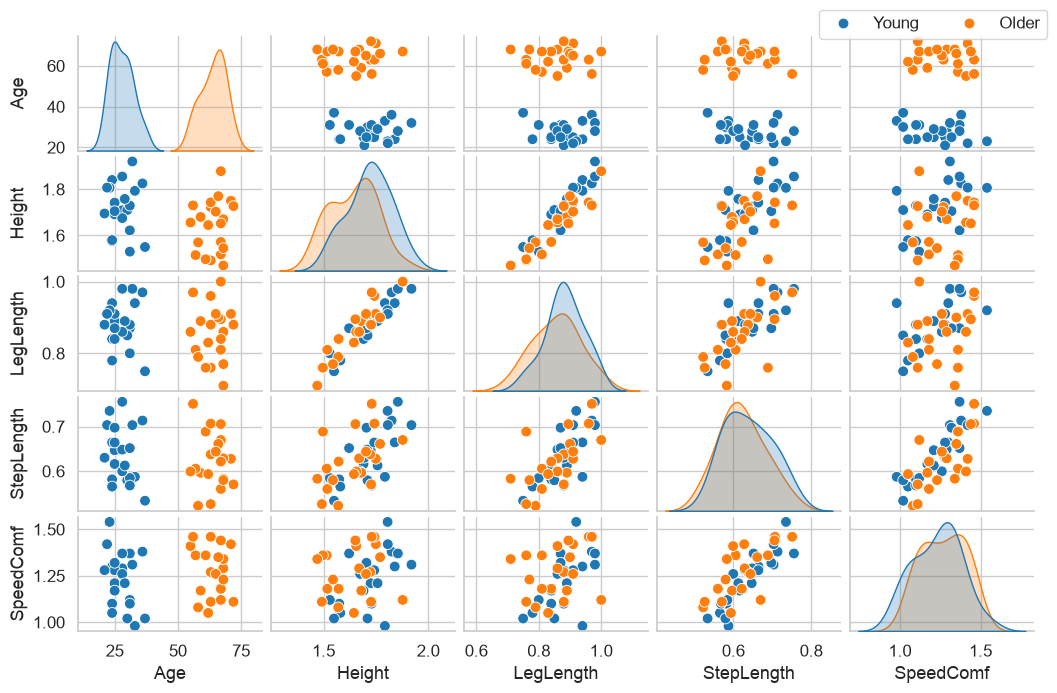

In [9]:
grid = sns.pairplot(df[df['SpeedCat']=='V5'],
                    vars=['Age', 'Height', 'LegLength', 'StepLength', 'SpeedComf'],
                    diag_kind='auto', hue='AgeGroup', plot_kws={'s':60},
                    height=1.4, aspect=1.4)
handles = grid._legend_data.values()
labels = grid._legend_data.keys()
grid._legend.remove()
grid.fig.legend(handles=handles, labels=labels, loc='upper right', ncol=2,
                bbox_to_anchor=(1, 1.0), bbox_transform=plt.gcf().transFigure)
grid.fig.subplots_adjust(left=.1, right=.98, bottom = 0.1, top=.95, hspace=.05, wspace=.05)
grid.fig.align_ylabels(grid.axes[:, 0])
plt.show()

In [10]:
fig = px.scatter(df, x='Subject', y='Speed', color='AgeGroup',
                 hover_data=['LegLength', 'Cadence', 'StepLength'],
                 labels={'Speed': 'Speed [m/s]', 'Subject': 'Subject #'},
                 range_x=[0, df.Subject.max()+1],
                 title='Walking speeds of the subjects')
fig.show()

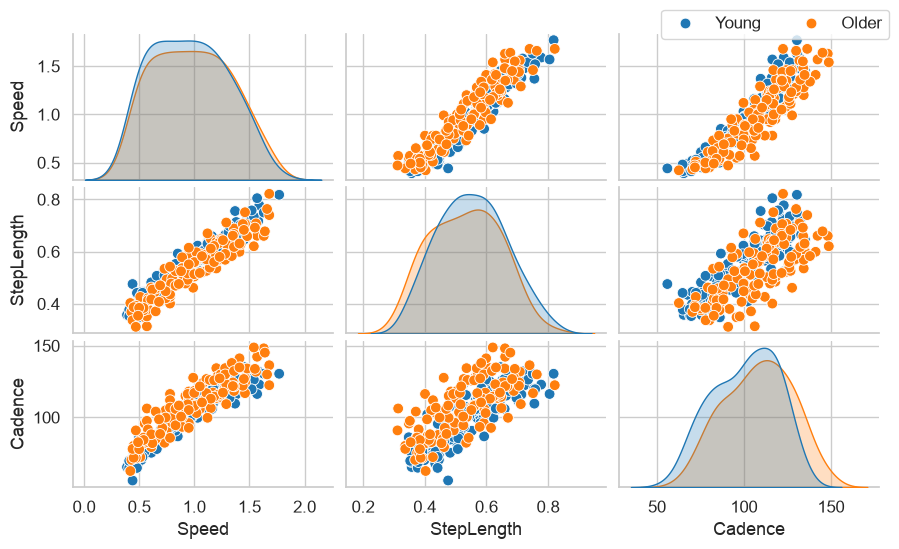

In [11]:
grid = sns.pairplot(df, vars=['Speed', 'StepLength', 'Cadence'],
                    diag_kind='auto', hue='AgeGroup', plot_kws={'s':60},
                    height=1.8, aspect=1.5)
handles = grid._legend_data.values()
labels = grid._legend_data.keys()
grid._legend.remove()
grid.fig.legend(handles=handles, labels=labels, loc='upper right', ncol=2,
             bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)
grid.fig.subplots_adjust(left=.1, right=.98, bottom = 0.1, top=.94, hspace=.05, wspace=.05)
grid.fig.align_ylabels(grid.axes[:, 0])
plt.show()

## Linear regression models

> Predictors: Age and Speed  
> Responses: StepLength and Cadence

### StepLength

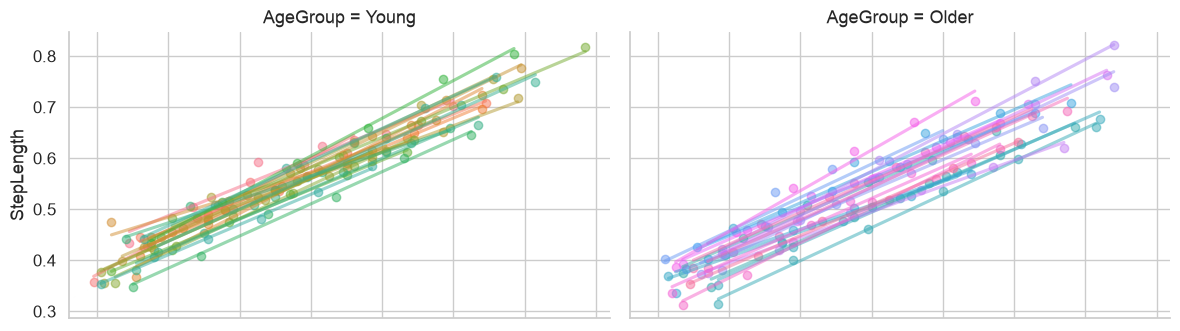

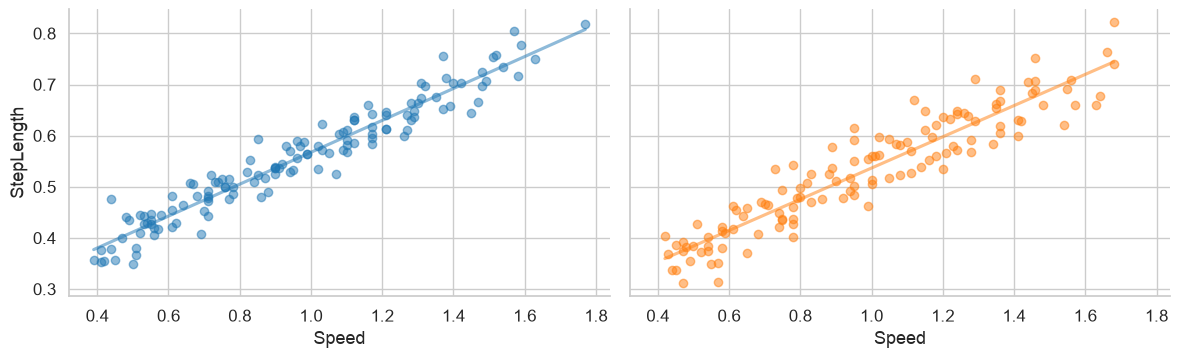

In [12]:
def plots(df, x, y):
    """Scatter and line plots
    """
    fig = px.scatter(df, x=x, y=y, color='AgeGroup',
                     hover_data=['Subject', 'StepLength', 'Cadence', 'SpeedComf'])
    fig.show()

    grid = sns.lmplot(x=x, y=y, data=df, order=1, hue='Subject', col='AgeGroup',
                      ci=None, robust=False, scatter_kws={'alpha':.5}, line_kws={'alpha':.5},
                      facet_kws={'sharex':True, 'sharey':True}, fit_reg=True, legend=False,
                      height=4, aspect=1.5)
    grid.set(xticklabels=[])
    grid.set_xlabels('')
    plt.show()

    grid = sns.lmplot(x=x, y=y, data=df, order=1, col='AgeGroup', hue='AgeGroup',
                      ci=None, robust=False, scatter_kws={'alpha':.5}, line_kws={'alpha':.5},
                      facet_kws={'sharex':True, 'sharey':True}, fit_reg=True, legend=False,
                      height=4, aspect=1.5)
    grid.set_titles(col_template='')
    plt.show()


plots(df, x='Speed', y='StepLength')

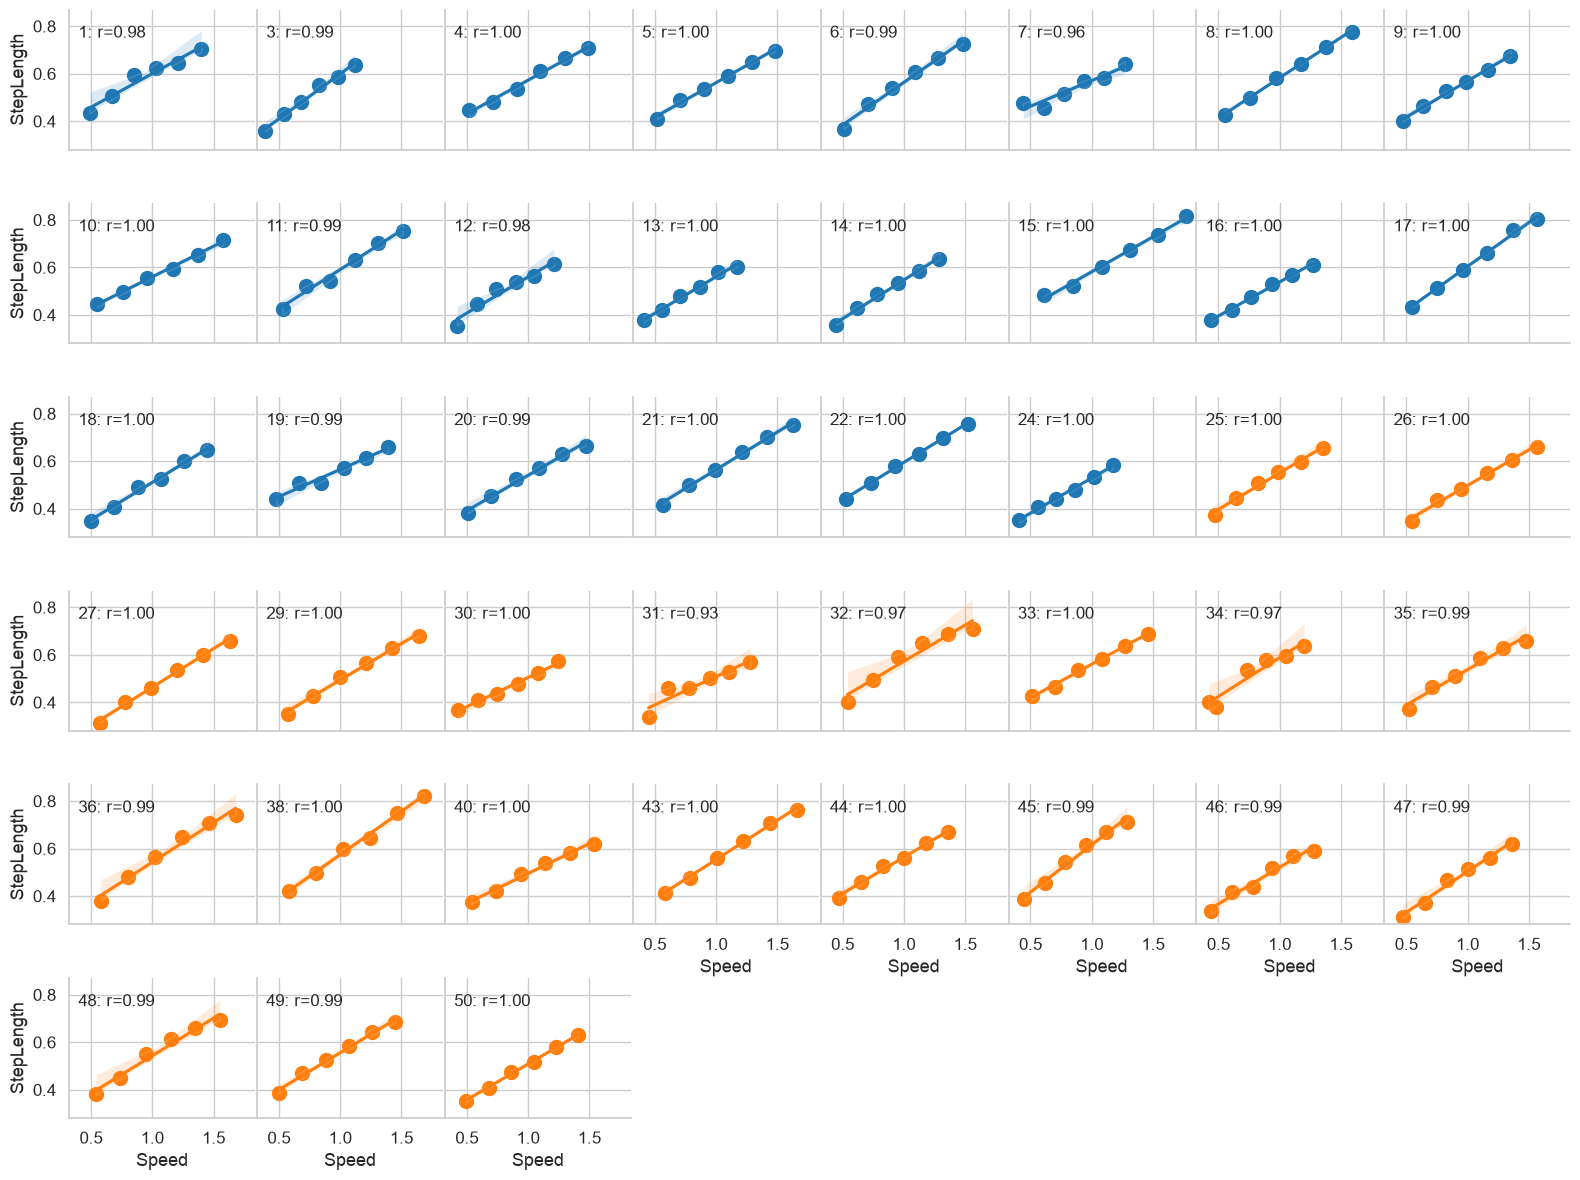

In [13]:
def plots2(df, x, y):
    """Scatter and line plots
    """
    grid = sns.lmplot(x=x, y=y, data=df, hue='AgeGroup', col='Subject',
                      col_wrap=8, ci=100*(1-alpha), robust=False, fit_reg=True,
                      height=2, aspect=1, scatter_kws={'alpha':1, 's':100},
                      facet_kws={'sharex':True, 'sharey':True, 'legend_out':False})
    grid.axes[0].legend(loc='best')
    grid.axes[int(len(grid.axes)/2-1)].legend(loc='best')

    def annotate(data, **kws):
        r, p = sp.stats.pearsonr(data['Speed'], data[y])
        ax = plt.gca()
        ax.text(.05, .8, '{}: r={:.2f}'.format(data['Subject'].to_numpy()[0], r), fontsize=12,
                transform=ax.transAxes)

    grid.map_dataframe(annotate)
    grid.set_titles(col_template='')
    plt.tight_layout(h_pad=0.1, w_pad=0.1)
    plt.show()

plots2(df, x='Speed', y='StepLength')

### Cadence

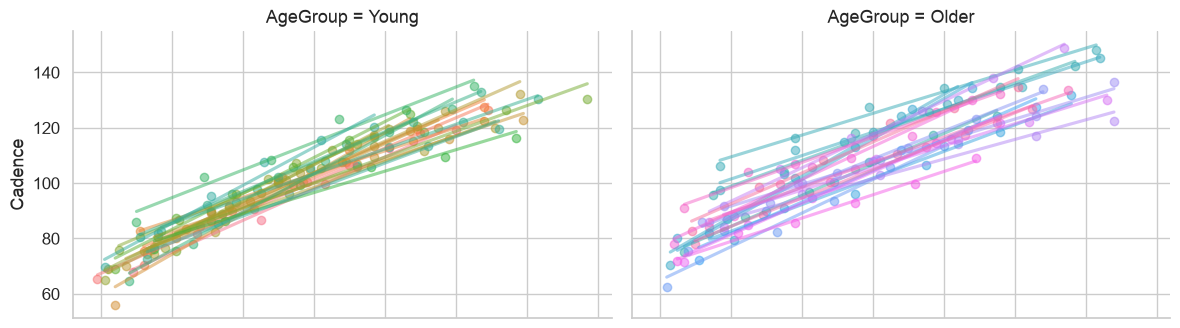

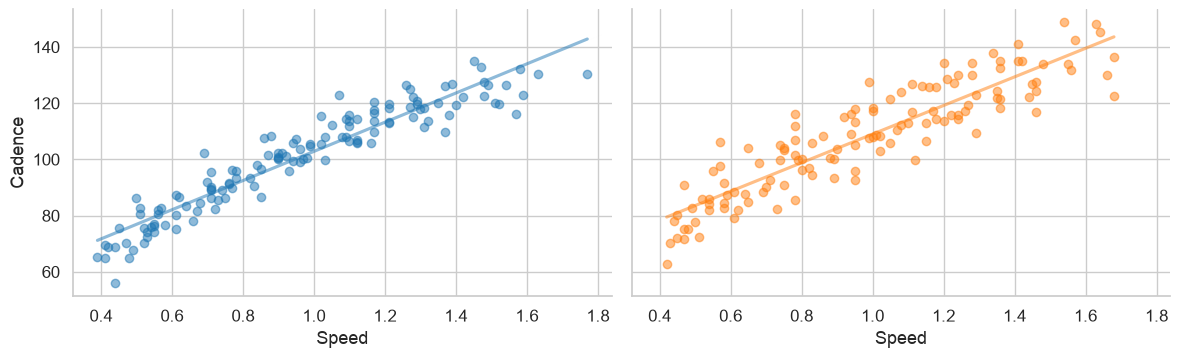

In [14]:
plots(df, x='Speed', y='Cadence')

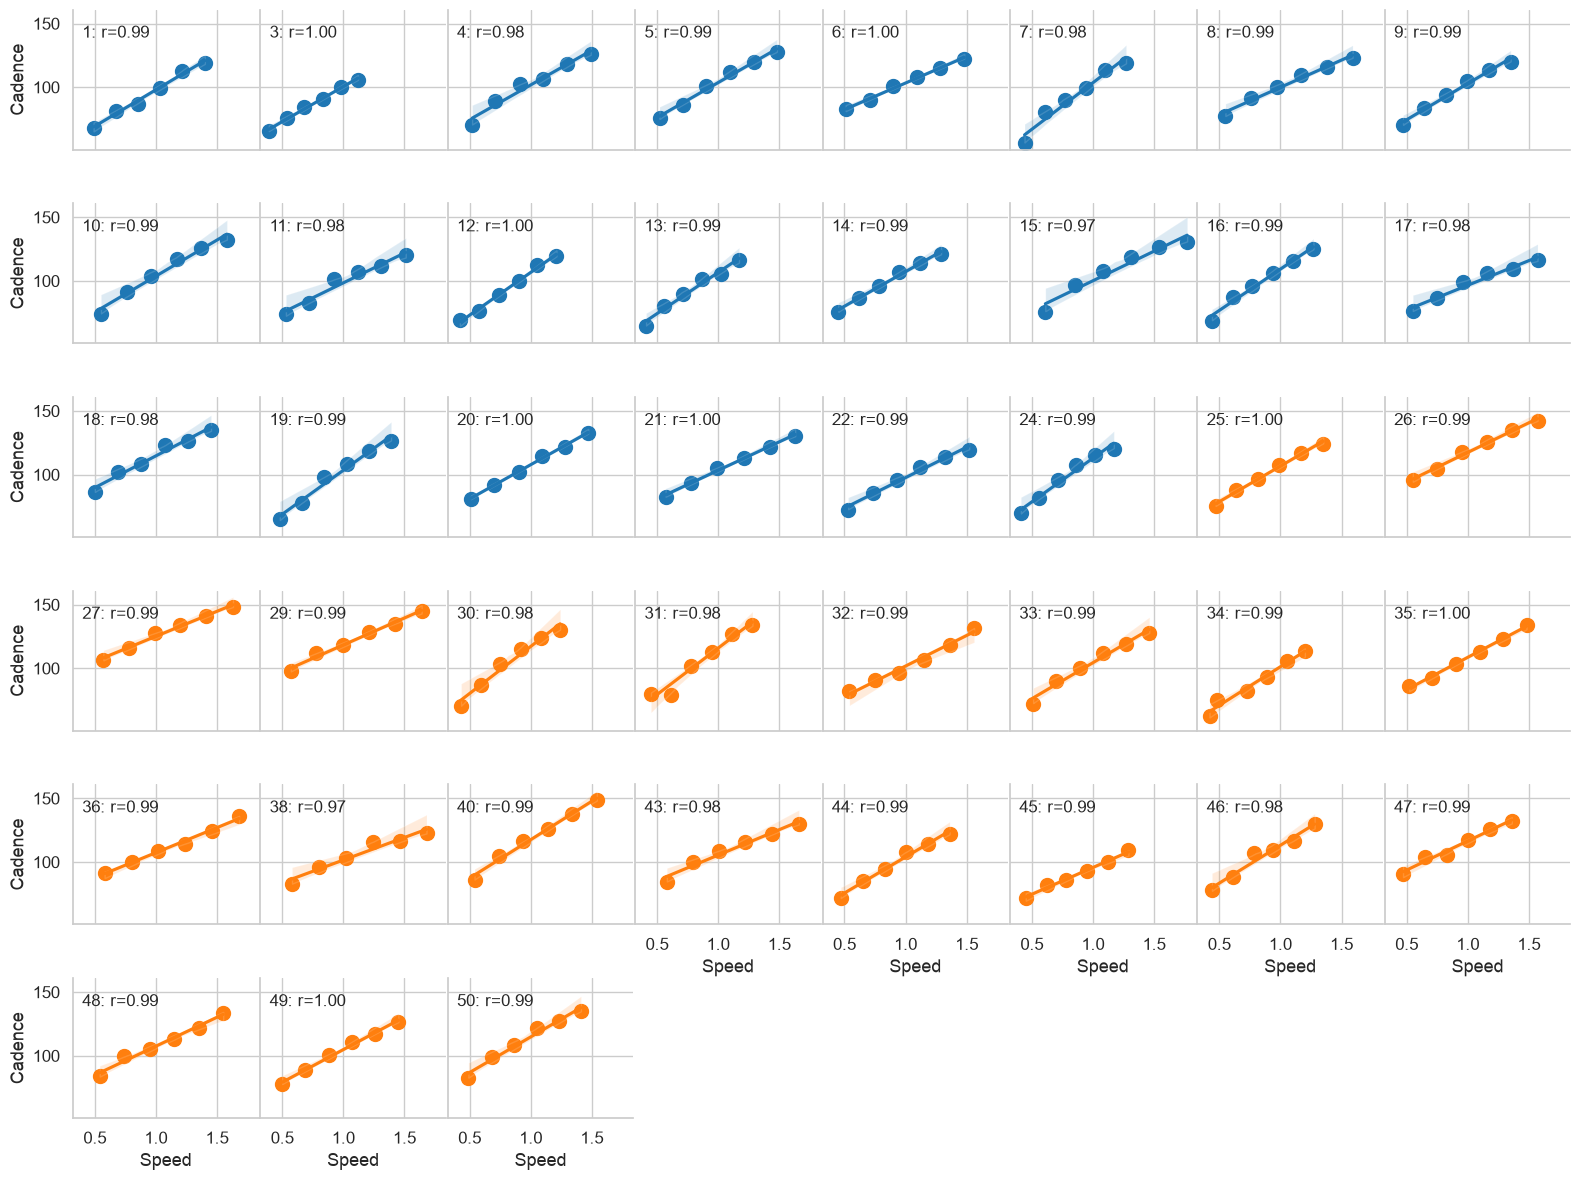

In [15]:
plots2(df, x='Speed', y='Cadence')

#### Quadratic polynomial for the relation between variables Speed and Cadence

A parabola (quadratic polynomial) captures better the relation between variables Speed and Cadence:

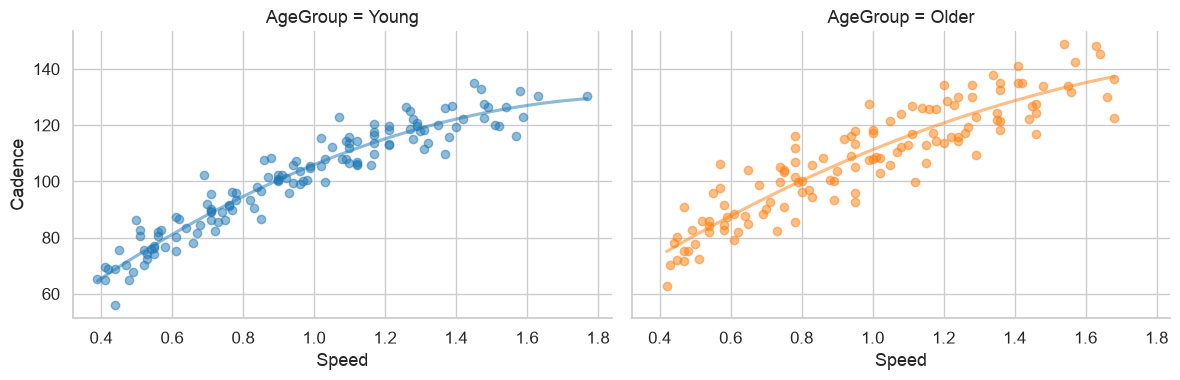

In [16]:
grid = sns.lmplot(x='Speed', y='Cadence', data=df, order=2, col='AgeGroup', hue='AgeGroup',
                  ci=None, robust=False, scatter_kws={'alpha':.5}, line_kws={'alpha':.5},
                  facet_kws={'sharex':True, 'sharey':True}, fit_reg=True, legend=False,
                  height=4, aspect=1.5)
plt.show()

### A linear mixed-effects regression model

Mixed-effects models examine age group and speed in repeated observations from 43 participants, each walking at six speeds. Speed-containing primary models allow a correlated random intercept and linear Speed slope for each participant. This accommodates individual differences in both baseline response and response to speed. Fixed effects include age group, linear and quadratic speed terms, and an age-by-speed interaction where specified:

$$
Y_{ij}=\beta_0+\beta_A A_i+\beta_S S_{ij}+\beta_{S2} S_{ij}^2+\beta_{AS}A_iS_{ij}+b_{0i}+b_{Si}S_{ij}+\epsilon_{ij}.
$$

The random intercept and slope have an estimated, unrestricted 2×2 covariance matrix. The age-only model remains a random-intercept descriptive reference; it is not used in a fixed-effect likelihood-ratio comparison against a model with a different random structure. Random-intercept-only versions of all formulas are retained as sensitivity analyses. ML is used for likelihood comparisons and AIC; separate REML fits supply fixed-effect estimates and confidence intervals.

#### Replace letters by numeric values because it's easier to identify the effect  
E.g.: {'Y': 0, 'O': 1} implies that if there is an effect of Age and its coefficient (slope) is positive, it means that the response increases for older subjects and decreases for young subjects. Internally the letters were replaced by numbers anyway but we didn't know the order.

In [17]:
df['AgeGroup'] = df['AgeGroup'].replace({'Young': 0, 'Older': 1}).astype(int)
#df['AgeGroup'] = df['AgeGroup'].cat.remove_unused_categories()

### Data standardization

Continuous predictors and outcomes are centered by their full-sample means and divided by their sample standard deviations (`ddof=1`). This expresses coefficients in SD units; it does **not** make distributions normal or enforce regression assumptions. Residual diagnostics are assessed separately. Age group is an unscaled categorical contrast (Young = 0, Older = 1).

In [18]:
dfraw = df.copy(deep=True)
var = ['Speed', 'Cadence', 'StepLength']
# Standardization (mean 0, variance 1)
df[var] = df[var].apply(lambda x: (x-x.mean())/x.std(ddof=1), axis=0)

### Run regression models

In [19]:
# https://stackoverflow.com/questions/31978948/python-stats-models-quadratic-term-in-regression
df['Speed2'] = df['Speed']**2

features = ['StepLength', 'Cadence']
labels   = ['StepLength', 'Cadence']

predictors = ['C(AgeGroup)',
              'Speed',
              'C(AgeGroup) + Speed',
              'Speed + Speed2',
              'C(AgeGroup) + Speed + Speed2',
              'C(AgeGroup) * Speed',
              'C(AgeGroup) * Speed + Speed2']
groups = df['Subject']

names = ['C(AgeGroup)[T.1]', 'Speed', 'Speed2', 'C(AgeGroup)[T.1]:Speed']
models, fit_ml, fit_re = runmodels(df, predictors, features, groups, names)
# Retain the former random-intercept analysis as a named sensitivity.
models_ri, fit_ml_ri, fit_re_ri = runmodels(df, predictors, features, groups, names, random_slopes=False)

/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model  1: StepLength ~ C(AgeGroup); ML and REML converged.
Model  2: StepLength ~ Speed; ML and REML converged.


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model  3: StepLength ~ C(AgeGroup) + Speed; ML and REML converged.


Model  4: StepLength ~ Speed + Speed2; ML and REML converged.


...

Model  2: StepLength ~ Speed; ML and REML converged.
Model  3: StepLength ~ C(AgeGroup) + Speed; ML and REML converged.
Model  4: StepLength ~ Speed + Speed2; ML and REML converged.


Model  5: StepLength ~ C(AgeGroup) + Speed + Speed2; ML and REML converged.
Model  6: StepLength ~ C(AgeGroup) * Speed; ML and REML converged.
Model  7: StepLength ~ C(AgeGroup) * Speed + Speed2; ML and REML converged.


Model  8: Cadence ~ C(AgeGroup); ML and REML converged.
Model  9: Cadence ~ Speed; ML and REML converged.
Model 10: Cadence ~ C(AgeGroup) + Speed; ML and REML converged.


Model 11: Cadence ~ Speed + Speed2; ML and REML converged.
Model 12: Cadence ~ C(AgeGroup) + Speed + Speed2; ML and REML converged.


Model 13: Cadence ~ C(AgeGroup) * Speed; ML and REML converged.
Model 14: Cadence ~ C(AgeGroup) * Speed + Speed2; ML and REML converged.


In [20]:
display(fit_re[0].summary())
display(fit_re[1].summary())
display(fit_re[2].summary())
display(fit_re[3].summary())

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
===========================================================
Model:             MixedLM  Dependent Variable:  StepLength
No. Observations:  258      Method:              REML      
No. Groups:        43       Scale:               0.9886    
Min. group size:   6        Log-Likelihood:      -367.3359 
Max. group size:   6        Converged:           Yes       
Mean group size:   6.0                                     
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.097    0.088  1.097 0.273 -0.076  0.269
C(AgeGroup)[T.1] -0.198    0.126 -1.570 0.116 -0.445  0.049
Group Var         0.006    0.041                           
===========================================================

"""

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM  Dependent Variable:  StepLength
No. Observations:   258      Method:              REML      
No. Groups:         43       Scale:               0.0194    
Min. group size:    6        Log-Likelihood:      41.0640   
Max. group size:    6        Converged:           Yes       
Mean group size:    6.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.003    0.047 -0.066 0.947 -0.095  0.088
Speed              0.943    0.017 54.594 0.000  0.909  0.976
Group Var          0.090    0.165                           
Group x Speed Cov  0.010    0.041                           
Speed Var          0.009    0.023                           
============================================================

"""

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM  Dependent Variable:  StepLength
No. Observations:   258      Method:              REML      
No. Groups:         43       Scale:               0.0193    
Min. group size:    6        Log-Likelihood:      45.4020   
Max. group size:    6        Converged:           Yes       
Mean group size:    6.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.138    0.057  2.420 0.016  0.026  0.249
C(AgeGroup)[T.1]  -0.289    0.079 -3.664 0.000 -0.443 -0.134
Speed              0.943    0.017 54.581 0.000  0.909  0.977
Group Var          0.072    0.134                           
Group x Speed Cov  0.011    0.038                           
Speed Var          0.009    0.023                           
============================================================

"""

<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM  Dependent Variable:  StepLength
No. Observations:   258      Method:              REML      
No. Groups:         43       Scale:               0.0151    
Min. group size:    6        Log-Likelihood:      54.7965   
Max. group size:    6        Converged:           Yes       
Mean group size:    6.0                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.046    0.047  0.979 0.328 -0.046  0.139
Speed              0.944    0.019 49.346 0.000  0.906  0.981
Speed2            -0.060    0.010 -6.297 0.000 -0.079 -0.041
Group Var          0.091    0.187                           
Group x Speed Cov  0.010    0.051                           
Speed Var          0.013    0.032                           
============================================================

"""

#### Primary random-slope models and random-intercept sensitivity

In [21]:
names2 = [['Age'], ['Speed'], ['Speed^2'], ['Age × Speed']]
print('Primary models: correlated random intercept and Speed slope (age-only reference: random intercept)')
display(display_table(models, names2, filename='sl_c_age_speed.csv'))
print('Random-intercept sensitivity: identical fixed-effect formulas')
display(display_table(models_ri, names2, filename='sl_c_age_speed_ri.csv'))

Primary models: correlated random intercept and Speed slope (age-only reference: random intercept)


Random-intercept sensitivity: identical fixed-effect formulas


#### Partial regression plots

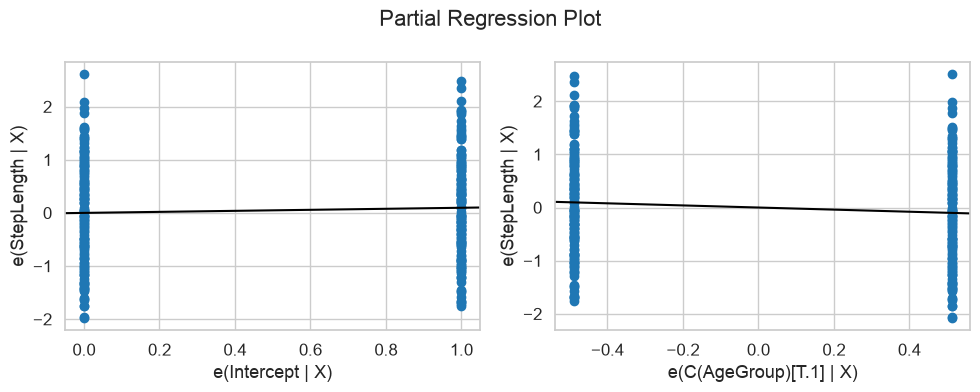

In [22]:
fig = plt.figure(figsize=(10, 4))
fig = sm.graphics.plot_partregress_grid(fit_re[0], grid=(1, 2), fig=fig)
plt.tight_layout()

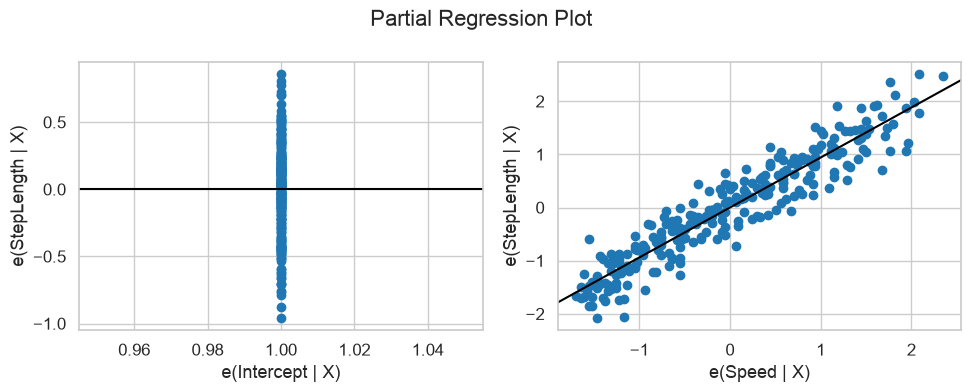

In [23]:
fig = plt.figure(figsize=(10, 4))
fig = sm.graphics.plot_partregress_grid(fit_re[1], grid=(1, 2), fig=fig)
plt.tight_layout()

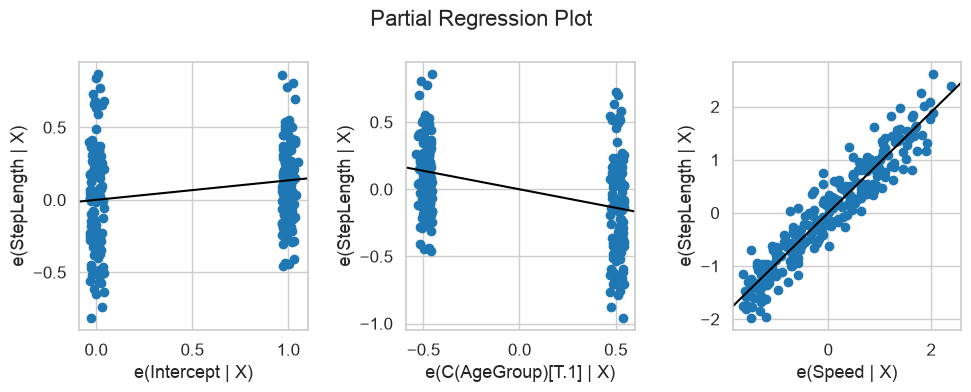

In [24]:
fig = plt.figure(figsize=(10, 4))
sm.graphics.plot_partregress_grid(fit_re[2], grid=(1, 3), fig=fig)
plt.tight_layout()

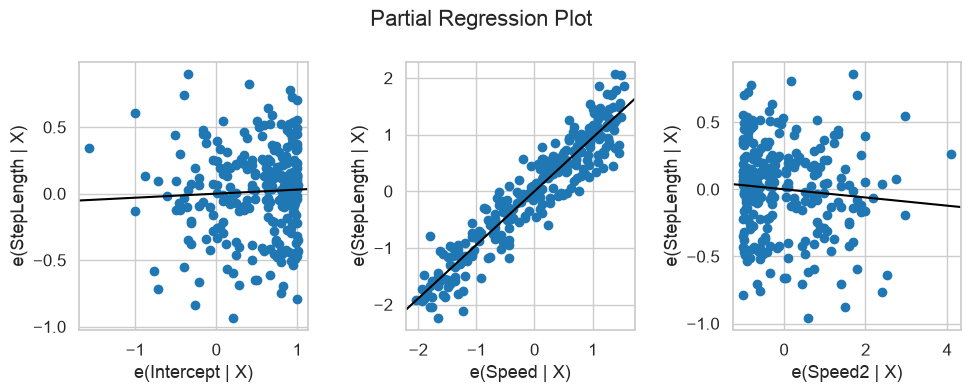

In [25]:
fig = plt.figure(figsize=(10, 4))
sm.graphics.plot_partregress_grid(fit_re[3], grid=(1, 3), fig=fig)
plt.tight_layout()

#### Residual diagnostics and exploratory leave-out sensitivity

Residual patterns motivate a sensitivity check omitting participants 7 and 31. Primary inference retains all 43 participants. Normality is not established by deleting observations, and sensitivity of coefficients and interactions is reported below.

In [26]:
plot_residuals(fit=fit_re[1], kind='conditional', xlabel='Speed', ylabel='StepLength',
               hover=('Subject', df['Subject']));

We reject the null hypothesis that the residuals come from a population with normal distribution
(Shapiro-Wilk test: W(258) = 0.98, p = 0.006).


In [27]:
assert df.Subject.nunique() == 43 and len(df) == 258
df2 = df.loc[~df.Subject.isin([7, 31])].copy()
assert df2.Subject.nunique() == 41 and len(df2) == 246
assert set(df.Subject.unique()) - set(df2.Subject.unique()) == {7, 31}
groups2 = df2['Subject']
models_leaveout, fit_ml_leaveout, fit_re_leaveout = runmodels(df2, predictors, features, groups2, names)
display_table(models_leaveout, names2, filename=None)

Model  1: StepLength ~ C(AgeGroup); ML and REML converged.


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model  2: StepLength ~ Speed; ML and REML converged.


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model  3: StepLength ~ C(AgeGroup) + Speed; ML and REML converged.


...

Model  9: Cadence ~ Speed; ML and REML converged.


Model 10: Cadence ~ C(AgeGroup) + Speed; ML and REML converged.


Model 11: Cadence ~ Speed + Speed2; ML and REML converged.


Model 12: Cadence ~ C(AgeGroup) + Speed + Speed2; ML and REML converged.
Model 13: Cadence ~ C(AgeGroup) * Speed; ML and REML converged.


Model 14: Cadence ~ C(AgeGroup) * Speed + Speed2; ML and REML converged.


In [28]:
plot_residuals(fit=fit_re_leaveout[1], kind='conditional', xlabel= 'Speed', ylabel='StepLength',
               hover=('Subject', df2['Subject']));

We failed to reject the null hypothesis that the residuals come from a population with normal distribution
(Shapiro-Wilk test: W(246) = 0.99, p = 0.330).


## Two-dimensional plots combined: Step Length and Cadence versus Speed

### Fresh quadratic fits and confidence intervals for fixed-effect means

Both outcomes use a quadratic Speed term, supported by full-sample ML likelihood-ratio comparisons below. Both fits include correlated participant random intercepts and Speed slopes. Bands use the covariance of the REML fixed effects from these random-slope models, $X\operatorname{Cov}(\hat\beta)X^T$, and a normal 1.96 multiplier. They are pointwise mean confidence intervals, not prediction intervals. The vertical band is a t interval for the mean of 43 subject-level comfortable speeds.

/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


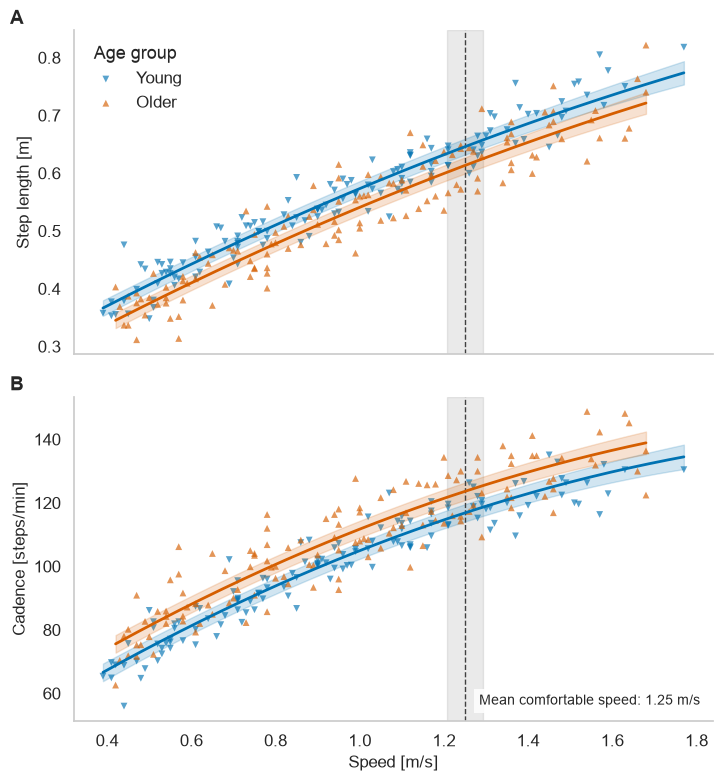

In [29]:
df = dfraw.copy(deep=True)
sys.path.insert(0, str(ROOT / 'scripts'))
from figure1 import make_figure1
figure1, figure1_fits, figure1_predictions = make_figure1(ROOT)
plt.show()
cadence_label = 'Cadence [steps/min]'

In [30]:
display(figure1_predictions.groupby(['outcome', 'AgeGroup']).head(2))

,Speed,AgeGroup,outcome,mean,ci_low,ci_high,fixed_mean_se,structure,formula,estimator
0,0.390,Young,StepLength,0.366,0.353,0.380,0.007,correlated_random_intercept_speed_slope,StepLength ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
1,0.399,Young,StepLength,0.370,0.357,0.383,0.007,correlated_random_intercept_speed_slope,StepLength ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
150,0.420,Older,StepLength,0.345,0.332,0.359,0.007,correlated_random_intercept_speed_slope,StepLength ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
151,0.428,Older,StepLength,0.348,0.335,0.362,0.007,correlated_random_intercept_speed_slope,StepLength ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
300,0.390,Young,Cadence,66.609,63.840,69.378,1.413,correlated_random_intercept_speed_slope,Cadence ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
301,0.399,Young,Cadence,67.290,64.537,70.042,1.404,correlated_random_intercept_speed_slope,Cadence ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
450,0.420,Older,Cadence,75.580,72.811,78.349,1.413,correlated_random_intercept_speed_slope,Cadence ~ C(AgeGroup) + Speed + I(Speed ** 2),REML
451,0.428,Older,Cadence,76.193,73.437,78.948,1.406,correlated_random_intercept_speed_slope,Cadence ~ C(AgeGroup) + Speed + I(Speed ** 2),REML


In [31]:
assert all(fit.converged and fit.model.k_re == 2 for fit in figure1_fits.values())

In [32]:
print('Figure 1 saved as figures/figure1.png and figure1.svg')

Figure 1 saved as figures/figure1.png and figure1.svg


Figure 1. Step length (A) and cadence (B) versus speed in 22 young and 21 older adults, each observed at six speeds (258 observations). Curves show full-sample mixed models with correlated participant random intercepts and linear Speed slopes with AgeGroup + Speed + Speed²; shading gives pointwise 95% confidence intervals for fixed-effect means. The vertical line and gray band show the overall subject-level mean comfortable speed and its 95% t confidence interval (43 independent subjects). The additive model is a descriptive simplification; lack of a detected full-sample interaction does not establish equal age-specific slopes.

## Three-dimensional plots: Step Length and Cadence versus Speed

In [33]:
# add plane: https://memotut.com/en/e42c726cdee25767105d/
df['AgeGroup'] = df['AgeGroup'].replace({0: 'Young', 1: 'Older'}).astype(str)
fig = px.scatter_3d(df, x='StepLength', y='Cadence', z='Speed', color='AgeGroup',
                    labels={'StepLength': 'Step Length [m]', 'Cadence': cadence_label,
                            'Speed': 'Speed [m/s]'},
                    width=800, height=600)
fig.update_traces(marker=dict(size=5), selector=dict(mode='markers'))
camera = dict(up=dict(x=0, y=0, z=1), center=dict(x=0, y=0, z=0), eye=dict(x=1, y=-2, z=0.5))
fig.update_layout(scene_camera=camera)
fig.show()

## Revision analyses: random structure, nested ML comparisons, and sensitivity

Nested fixed-effect formulas are compared by ML with the same correlated random-intercept/Speed-slope structure and observations. REML supplies coefficient estimates and intervals. The full-sample and existing leave-out analyses retain the same full-sample standardization. All 104 primary/reference and random-intercept-sensitivity ML/REML fits must converge; covariance eigenvalues, intercept/slope variances, and correlations are exported. A further 36 body-size sensitivity fits are reported below. Tests are exploratory and unadjusted for multiple comparisons.

Random-structure comparisons report LLF, AIC, and descriptive twice-log-likelihood differences. Testing a zero slope variance places the null on a covariance boundary, so a conventional chi-square test with two degrees of freedom is not used to assign a calibrated p value.

In [34]:
sys.path.insert(0, str(ROOT / 'notebooks'))
from revision_analysis import experiment1
revision_exp1 = experiment1()
print('Primary fixed-effect likelihood-ratio tests')
display(revision_exp1['lrt'][['outcome', 'sample', 'term', 'lr', 'df', 'p']])
print('Primary fixed-effect coefficients: full sample')
display(revision_exp1['coefficients'].query("sample == 'full'")[['model', 'outcome', 'term', 'estimate', 'ci_low', 'ci_high', 'p', 'structure']])
print('Existing leave-out sensitivity coefficients')
display(revision_exp1['coefficients'].query("sample == 'omit_7_31'")[['model', 'outcome', 'term', 'estimate', 'ci_low', 'ci_high', 'p']])
print('Random-intercept fixed-effect likelihood-ratio sensitivity')
display(revision_exp1['ri_lrt'][['outcome', 'sample', 'term', 'lr', 'p']])

/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/marcos/github/bmclab/h2a_age_spt/.venv/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

,model,outcome,term,estimate,ci_low,ci_high,p,structure
0,1,StepLength,Intercept,0.097,-0.076,0.269,2.727e-01,random_intercept_age_only_reference
1,1,StepLength,AgeGroup,-0.198,-0.445,0.049,1.165e-01,random_intercept_age_only_reference
2,2,StepLength,Intercept,-0.003,-0.095,0.088,9.470e-01,correlated_random_intercept_speed_slope
3,2,StepLength,Speed,0.943,0.909,0.976,0.000e+00,correlated_random_intercept_speed_slope
4,3,StepLength,Intercept,0.138,0.026,0.249,1.551e-02,correlated_random_intercept_speed_slope
5,3,StepLength,AgeGroup,-0.289,-0.443,-0.134,2.488e-04,correlated_random_intercept_speed_slope
6,3,StepLength,Speed,0.943,0.909,0.977,0.000e+00,correlated_random_intercept_speed_slope
7,4,StepLength,Intercept,0.046,-0.046,0.139,3.276e-01,correlated_random_intercept_speed_slope
8,4,StepLength,Speed,0.944,0.906,0.981,0.000e+00,correlated_random_intercept_speed_slope
9,4,StepLength,Speed2,-0.060,-0.079,-0.041,3.036e-10,correlated_random_intercept_speed_slope


Existing leave-out sensitivity coefficients


,model,outcome,term,estimate,ci_low,ci_high,p
46,1,StepLength,Intercept,1.023e-01,-0.075,0.280,2.583e-01
47,1,StepLength,AgeGroup,-1.785e-01,-0.433,0.075,1.684e-01
48,2,StepLength,Intercept,-1.525e-04,-0.094,0.094,9.975e-01
49,2,StepLength,Speed,9.537e-01,0.922,0.985,0.000e+00
50,3,StepLength,Intercept,1.336e-01,0.018,0.249,2.319e-02
51,3,StepLength,AgeGroup,-2.746e-01,-0.433,-0.116,7.024e-04
52,3,StepLength,Speed,9.538e-01,0.922,0.985,0.000e+00
53,4,StepLength,Intercept,5.254e-02,-0.042,0.148,2.783e-01
54,4,StepLength,Speed,9.574e-01,0.923,0.992,0.000e+00
55,4,StepLength,Speed2,-6.230e-02,-0.080,-0.045,1.526e-12


Random-intercept fixed-effect likelihood-ratio sensitivity


,outcome,sample,term,lr,p
0,StepLength,full,AgeGroup:Speed (linear),0.504,4.778e-01
1,StepLength,full,AgeGroup:Speed (quadratic),0.884,3.471e-01
2,StepLength,full,Speed2,9.919,1.636e-03
3,StepLength,full,AgeGroup,10.000,1.566e-03
4,Cadence,full,AgeGroup:Speed (linear),3.942,4.709e-02
5,Cadence,full,AgeGroup:Speed (quadratic),3.496,6.150e-02
6,Cadence,full,Speed2,112.547,2.712e-26
7,Cadence,full,AgeGroup,10.745,1.046e-03
8,StepLength,omit_7_31,AgeGroup:Speed (linear),0.436,5.089e-01
9,StepLength,omit_7_31,AgeGroup:Speed (quadratic),0.959,3.274e-01


For the full-sample random-slope models, adding Speed² improves fit for step length (LR = 34.746, p < .001) and cadence (LR = 91.868, p < .001). Age-group offsets remain after Speed and Speed² adjustment: step length −0.292 outcome SD (95% CI −0.448 to −0.136), and cadence +0.351 SD (0.165 to 0.537). Age likelihood-ratio statistics are 12.191 (p = .000480) and 12.377 (p = .000435), respectively.

Age × Speed tests in quadratic models give p = .521 for step length and .256 for cadence. The existing leave-out cadence interaction gives p = .193 with the random-slope structure. These estimates and intervals do not establish equal age-specific slopes; interaction inference also depends on the random structure and on the speed/size parameterization considered below.

In [35]:
print('Random-structure comparison, full-sample additive quadratic models')
display(revision_exp1['random_structure'].query("sample == 'full' and model in [5, 12]")[['outcome', 'ri_llf', 'rs_llf', 'ri_aic', 'rs_aic', 'descriptive_lr']])
print('REML covariance diagnostics, full-sample primary models')
display(revision_exp1['diagnostics'].query("sample == 'full' and role == 'primary' and estimator == 'REML'")[['model', 'outcome', 'converged', 'intercept_variance', 'slope_variance', 'intercept_slope_correlation', 'min_eigenvalue']])
assert revision_exp1['diagnostics'].converged.all()
assert revision_exp1['body_size_diagnostics'].converged.all()

Random-structure comparison, full-sample additive quadratic models


,outcome,ri_llf,rs_llf,ri_aic,rs_aic,descriptive_lr
3,StepLength,40.071,69.886,-68.143,-123.771,59.629
9,Cadence,18.846,46.445,-25.693,-76.889,55.196


REML covariance diagnostics, full-sample primary models


,model,outcome,converged,intercept_variance,slope_variance,intercept_slope_correlation,min_eigenvalue
5,2,StepLength,True,0.090,0.009,0.341,0.008
9,3,StepLength,True,0.072,0.009,0.421,0.007
13,4,StepLength,True,0.091,0.013,0.290,0.012
17,5,StepLength,True,0.074,0.013,0.380,0.011
21,6,StepLength,True,0.073,0.009,0.424,0.007
25,7,StepLength,True,0.074,0.013,0.382,0.011
31,9,Cadence,True,0.120,0.027,0.137,0.026
35,10,Cadence,True,0.096,0.027,0.258,0.024
39,11,Cadence,True,0.122,0.015,0.145,0.015
43,12,Cadence,True,0.097,0.015,0.269,0.014


### Body-size sensitivity: physical versus dimensionless speed

Using leg length $L$ in metres and $g=9.81\,\mathrm{m/s^2}$, dimensionless step length is StepLength/$L$, dimensionless cadence is (Cadence/60)$\sqrt{L/g}$, and dimensionless speed is Speed/$\sqrt{gL}$. Cadence in the source CSV is steps/minute. The first sensitivity normalizes the outcomes while holding physical speed (m/s) fixed; the second normalizes both outcomes and speed. These answer different conditional questions. A third keeps the original physical units and adds leg length as a covariate. All include correlated random intercepts and slopes for the speed variable actually used.

The table first shows additive quadratic age contrasts, followed by nested age and interaction tests. Comparing AIC across differently transformed outcomes is not an appropriate way to choose between these definitions.

In [36]:
body_age = revision_exp1['body_size'].loc[
    revision_exp1['body_size'].term.eq('AgeGroup') &
    revision_exp1['body_size'].model.str.endswith('_additive')]
display(body_age[['setting', 'outcome', 'speed_variable', 'estimate', 'ci_low', 'ci_high', 'p']])
display(revision_exp1['body_size_lrt'][['setting', 'outcome', 'term', 'lr', 'p']])

,setting,outcome,speed_variable,estimate,ci_low,ci_high,p
4,hof_physical_speed,StepLengthHof,Speed,-0.015,-0.042,0.012,0.279
16,hof_physical_speed,CadenceHof,Speed,0.020,0.004,0.037,0.014
28,hof_dimensionless_speed,StepLengthHof,SpeedHof,-0.019,-0.040,0.003,0.092
40,hof_dimensionless_speed,CadenceHof,SpeedHof,0.015,-0.004,0.033,0.119
53,leg_length_covariate,StepLength,Speed,-0.025,-0.041,-0.008,0.004
68,leg_length_covariate,Cadence,Speed,4.664,1.211,8.118,0.008


,setting,outcome,term,lr,p
0,hof_physical_speed,StepLengthHof,AgeGroup,1.209,0.272
1,hof_physical_speed,StepLengthHof,AgeGroup:Speed,3.284,0.070
2,hof_physical_speed,CadenceHof,AgeGroup,5.893,0.015
3,hof_physical_speed,CadenceHof,AgeGroup:Speed,3.223,0.073
4,hof_dimensionless_speed,StepLengthHof,AgeGroup,2.874,0.090
5,hof_dimensionless_speed,StepLengthHof,AgeGroup:SpeedHof,2.214,0.137
6,hof_dimensionless_speed,CadenceHof,AgeGroup,2.460,0.117
7,hof_dimensionless_speed,CadenceHof,AgeGroup:SpeedHof,4.129,0.042
8,leg_length_covariate,StepLength,AgeGroup,8.121,0.004
9,leg_length_covariate,StepLength,AgeGroup:Speed,0.408,0.523


At matched physical speed, the normalized age contrast is −0.0151 for step length (95% CI −0.0424 to 0.0122) and +0.0205 for cadence (0.00416 to 0.0368). At matched dimensionless speed, the additive contrasts are −0.0187 (−0.0404 to 0.00304) and +0.0145 (−0.00376 to 0.0328). The dimensionless-cadence × dimensionless-speed age interaction has an exploratory ML LRT p = .0422. This cautions against a general statement that age-specific slopes are identical.

With leg length as a covariate instead of dividing outcomes by it, the age contrast remains −0.0245 m for step length (−0.0412 to −0.00788) and +4.664 steps/min for cadence (1.211 to 8.118). Body-size normalization and covariate adjustment impose different models; threshold changes do not establish that body size fully explains the associations.

## References
 - C.A. Fukuchi, R.K. Fukuchi, M. Duarte, A public dataset of overground and treadmill walking kinematics and kinetics in healthy individuals, PeerJ. 6 (2018) e4640. https://doi.org/10.7717/peerj.4640.  